# Analysis of extracted catalyst layer

In [1]:
import skimage #scikit-image version 0.22.0
import os
import matplotlib.pyplot as plt #matplotlib version 3.7.3
from matplotlib import cm #matplotlib version 3.7.3
from matplotlib.colors import Normalize #matplotlib version 3.7.3
from mpl_toolkits.axes_grid1 import make_axes_locatable #matplotlib version 3.7.3
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar #matplotlib version 3.7.3
import matplotlib.font_manager as fm #matplotlib version 3.7.3
import numpy as np #numpy version 1.26.4
from datetime import datetime
import json
import pandas as pd #pandas version 2.2.1
import skimage.io #scikit-image version 0.22.0

# workaround until galvani pip module can handle  EClab v11.5
cwd = os.getcwd()
os.chdir('/mpc/homes/fische_r/lib/python_playground') #path where BioLogic.py sits
import BioLogic 
os.chdir(cwd)

In [2]:
toppath = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem'

### show all data

In [3]:
series = ['A', 'B', 'C', 'Z', 'D', 'E', 'G']

def get_series_sample(series):
    series_path = os.path.join(toppath, series+'_series')
    folders = os.listdir(series_path)
    samples = []
    for sample in folders:
        samples.append(sample.split('_')[-1])
    paths = []
    for sample in samples:
        if series == 'Z' and sample in ['1', '2', '6']: continue
        sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
    
        files = os.listdir(sample_path)
        stages = []
        for file in files:
            splitfile = file.split('_')
            if splitfile[-1] == 'rotcrop.tif':
                stage = ''.join([i+'_' for i in splitfile[2:-1]])
                stages.append(stage)
        for stage in stages:
            imroot = series+'_'+sample+'_'+stage
            outpath = os.path.join(sample_path, 'CL_extraction')
            path = os.path.join(outpath, imroot+'_extracted_CL.tif')
            # print(path)
            paths.append((series, sample, stage[:-1], path))
    return paths

image_paths = get_series_sample('A') + get_series_sample('B') + get_series_sample('C') + get_series_sample('Z')+ get_series_sample('D')+ get_series_sample('E')+ get_series_sample('G')



In [4]:
for impath in image_paths:
    # print(impath)
    ser = impath[0]
    sample = impath[1]
    if ser+'_'+sample == 'Z_7':
        image_paths.remove(impath)
        continue

In [7]:
## put images into dict
image_dict = {}
image_dict['A'] = {}
image_dict['B'] = {}
image_dict['C'] = {}
image_dict['Z'] = {}
image_dict['D'] = {}
image_dict['E'] = {}
image_dict['G'] = {}

images = []
meds = []
for impath in image_paths:
    print(impath)
    ser = impath[0]
    sample = impath[1]
    if ser+'_'+sample == 'Z_7':
        image_paths.remove(impath)
        continue
    image_dict[ser][sample] = {}
    im = skimage.io.imread(impath[-1])
    images.append(im)

for (impath, im) in zip(image_paths, images):
    ser = impath[0]
    sample = impath[1]
    stage = impath[2]
    med = np.median(im[100:1100,50:550])
    diff = med -0.8
    image_dict[ser][sample][stage] = {'im': im, 'norm_im': im-diff}
    meds.append(med)
    

# flag = True
# for k in range(len(images)):
#     im = images[k]
#     med = meds[k]
#     #normalize im
#     diff = med - 0.8
#     normim = im - diff

('A', '13', 'postop_1', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_13/CL_extraction/A_13_postop_1__extracted_CL.tif')
('A', '13', 'preop', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_13/CL_extraction/A_13_preop__extracted_CL.tif')
('A', '3', 'postop_1', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_3/CL_extraction/A_3_postop_1__extracted_CL.tif')
('A', '3', 'postop_2', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_3/CL_extraction/A_3_postop_2__extracted_CL.tif')
('A', '3', 'preop', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_3/CL_extraction/A_3_preop__extracted_CL.tif')
('A', '9', 'postop_1', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_9/CL_extraction/A_9_postop_1__extracted_CL.tif')
('A', '9', 'preop', '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_9/CL_extraction/A_9_preop__extracted_CL.tif')
('A'

Text(0, 0.5, 'counts')

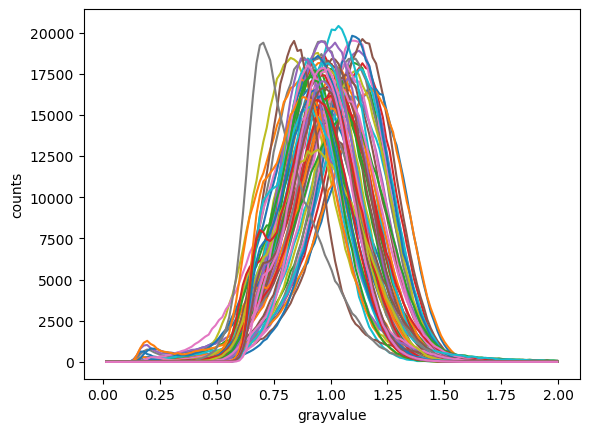

In [8]:
bins = np.arange(0,2, 1.5/100)
meds = []
for k in range(len(images)):
    im = images[k]
    impath = image_paths[k]
    ser = impath[0]
    sample = impath[1]
    # if not ser == 'C' or not sample == '2': continue
    med = np.median(im[100:1100,50:550])
    meds.append(med)
    hist = np.histogram(im[100:1100,50:550].flatten(), bins=bins)
    diff = med-0.8
    diff = 0
    if ser == 'Z' and sample == '4': continue
    if ser == 'C' and sample == '4' and impath[2] == 'preop': continue
    plt.plot(hist[1][1:]-diff, hist[0], label = impath[2])
plt.xlabel('grayvalue')
plt.ylabel('counts')
# plt.legend()

### Holes extracted from segmented CL

Scan C_4_preop is an outlier (originally C_4_preopb because of re-assembly), needs dedicated segmentation

In [9]:
with open(os.path.join(toppath, 'ABCZ_CLhole_segmented', 'CL_hole_area.csv')) as f:
    datalines = f.readlines()

with open(os.path.join(toppath, 'DE_CLhole_segmented', 'CL_hole_area.csv')) as f:
    datalines2 = f.readlines()

with open(os.path.join(toppath, 'G_CLhole_segmented', 'CL_hole_area.csv')) as f:
    datalines3 = f.readlines()

datalines = datalines + datalines2[1:] + datalines3[1:]

In [37]:
hole_dict = {}

for line in datalines[1:]:
    splitline = line.split(' , ')
    valstr = splitline[1]#1 for pseudo CFD, 2 for projection
    # valstr = splitline[2]#1 for pseudo CFD, 2 for projection
    if '\n' in valstr: valstr = valstr[:-1] # strip the newline character if necessary, pretty ugly and not robust, but works for the csv produced by 04_....
    val = float(valstr) 
    splitsplit =  splitline[0].split('_')
    ser = splitsplit[0]
    sample = splitsplit[1]
    stage = ''.join([i+'_' for i in splitsplit[2:]])[:-1]
    if not ser in hole_dict.keys(): hole_dict[ser] = {}
    if not sample in  hole_dict[ser].keys():  hole_dict[ser][sample] = {}
    hole_dict[ser][sample][stage] = val
        
    

In [11]:
def plot_absolute_hole_area(ab, current, i):
    ser = ab.split('_')[0]
    sample = ab.split('_')[1]
    color=cm.tab10(i)
    color_choices = {'A': 0, 'B': 1, 'C': 2, 'Z': 3}
    color = cm.tab10(color_choices[ser])
    for key in hole_dict[ser][sample].keys():
        val = hole_dict[ser][sample][key]
        Q = 0
        marker = 'o'
        if key == 'postop_1':
            Q = 1
            marker = '^'
        if key == 'postop_2':
            Q = 2
            marker = 's'
        if key=='preop':
            plt.plot(current, val, marker=marker, label=ser+'_'+sample, color=color)
        else:
            plt.plot(current, val, marker=marker,  color=color)

In [12]:
current_25 = ['A_3', 'B_2', 'C_4']
current_50 = ['A_4', 'B_1', 'C_1', 'D_2', 'E_3', 'G_1']
current_50_special = ['A_6', 'C_5']
current_80_special = ['A_11', 'A_9', 'B_4']
current_100 = ['A_12', 'C_2', 'D_1', 'E_4', 'G_2', 'G_3']
current_150 = ['C_3']#, 'Z_4'] # Z_4 pretty damaged during assembly
current_high_special = ['A_13', 'A_11']

KeyError: 'D'

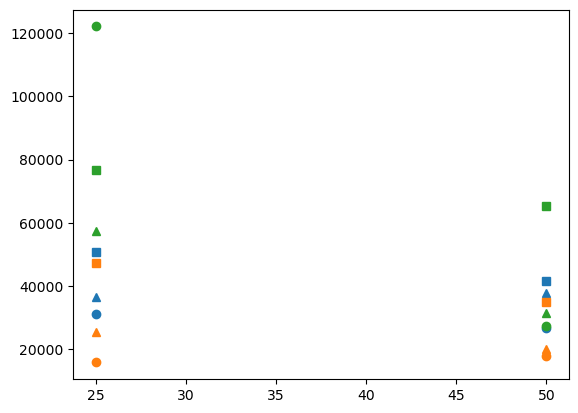

In [13]:
i = 0
for ab in current_25:
    plot_absolute_hole_area(ab, 25, i)
    i = i+1
i = 0
for ab in current_50:
    plot_absolute_hole_area(ab, 50, i)
    i = i+1
i = 0
for ab in current_100:
    plot_absolute_hole_area(ab, 100, i)
    i = i+1
i = 0
for ab in current_150:
    plot_absolute_hole_area(ab, 150, i)
    i = i+1
# i = 0
# for ab in current_80_special:
#     plot_absolute_hole_area(ab, 80, i)
#     i = i+1
plt.legend()   

### Electrochemistry

In [14]:
# TODO: extract exact charge for every sample to populate Xarray
# TODO: timestamp of CT to automatically extract echem charge

### nanotom time most of time wrong, roughly 10min, make automatic EClab file detection robust!!!

In [15]:
def get_raw_files(series, raw_file_dict):
    raw_file_dict[series] = {}
    series_path = os.path.join(toppath, series+'_series')
    folders = os.listdir(series_path)
    samples = []
    for sample in folders:
        samples.append(sample.split('_')[-1])
    paths = []
    for sample in samples:
        if series == 'Z' and sample in ['1', '2', '6']: continue
        if series == 'E' and sample in ['1', '2']: continue
        raw_file_dict[series][sample] = {}
        sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)
    
        files = os.listdir(sample_path)
        stages = []
        for file in files:
            splitfile = file.split('_')
            if splitfile[-1] == 'rotcrop.tif':
                stage = ''.join([i+'_' for i in splitfile[2:-1]])
                stages.append(stage)
        raw_files = []
        for stage in stages:
            imroot = series+'_'+sample+'_'+stage
            raw_file = os.path.join(sample_path, series+'_'+sample+'_'+stage[:-1], series+'_'+sample+'_'+stage+'.pcp')
            # print(raw_file)
            if os.path.exists(raw_file):
                raw_file_dict[series][sample][stage] = raw_file
            else:
                raw_file_dict[series][sample][stage] = None
                print(series+' '+sample+' '+stage+' pcp file not found.')

    return raw_file_dict

In [16]:
raw_file_dict = {}
raw_file_dict = get_raw_files('A',raw_file_dict) 
raw_file_dict = get_raw_files('B',raw_file_dict) 
raw_file_dict =get_raw_files('C',raw_file_dict) 
raw_file_dict =get_raw_files('Z',raw_file_dict)
raw_file_dict =get_raw_files('D',raw_file_dict)
raw_file_dict =get_raw_files('E',raw_file_dict)
raw_file_dict =get_raw_files('G',raw_file_dict)

A 3 postop_1_ pcp file not found.
A 9 postop_1_ pcp file not found.
A 11 postop_1_ pcp file not found.
A 6 postop_1_ pcp file not found.
B 5 postop_1_ pcp file not found.
B 4 postop_1_ pcp file not found.
B 2 postop_1_ pcp file not found.
B 6 wet_2_ pcp file not found.
C 5 postop_1_ pcp file not found.
C 1 postop_2_ pcp file not found.
Z 3 preop_ pcp file not found.
Z 4 postop_1_ pcp file not found.
Z 4 postop_2_ pcp file not found.
D 1 postop_2_ pcp file not found.
D 1 postop_1_ pcp file not found.


In [17]:
raw_file_dict['A']['3']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_3/A_1_postop_1/A_1_postop_1_.pcp'
raw_file_dict['A']['9']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_9/A_9_postop/A_9_postop_.pcp'
raw_file_dict['A']['11']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_11/A_11_postop/A_11_postop_.pcp'
raw_file_dict['A']['6']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/A_series/A_6/A_6_postop/A_6_postop_.pcp'
raw_file_dict['B']['5']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/B_series/B_5/B_5_postop/B_5_postop_.pcp'
raw_file_dict['B']['4']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/B_series/B_4/B_4_postop/B_4_postop_.pcp'
raw_file_dict['B']['2']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/B_series/B_2/B_2_postop1/B_2_postop1_.pcp'
raw_file_dict['B']['6']['wet_2_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/B_series/B_6/B_6_wet_2_40C/B_6_wet_2_40C_.pcp'
raw_file_dict['C']['5']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/C_series/C_5/C_5_postop/C_5_postop_.pcp'
raw_file_dict['C']['1']['postop_2_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/C_series/C_1/C_1_postop_2b/C_1_postop_2b_.pcp'
raw_file_dict['Z']['3']['preop_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/Z_series/Z_3/Z3_preop/Z3_preop_.pcp'
raw_file_dict['Z']['4']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/Z_series/Z_4/Z_4_postop1/Z_4_postop1_.pcp'
raw_file_dict['Z']['4']['postop_2_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/Z_series/Z_4/Z_4_postop2/Z_4_postop2_.pcp'
raw_file_dict['D']['1']['postop_1_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/D_series/D_1/D_1_postop1/D_1_postop1_.pcp'
raw_file_dict['D']['1']['postop_2_'] = '/mnt/nas_nanotomData/CT_Data_PSI/FR54/2023_COELY_postmortem/D_series/D_1/D_1_postop2/D_1_postop2_.pcp'

In [18]:
def read_timestamp_from_file(path):
    with open(path) as file:
        lines = file.readlines()
        timestamp = lines[500].split('\t')[-1][:-1] #line 500 in the middle of the acquisition to circumvent issue with clocks not macthcing between the different computers
    return timestamp

def convert_to_t_utc(timestamp):
    dtime = datetime.strptime(timestamp,'%Y-%m-%d %H:%M:%S')

def get_scan_timestamp(raw_file_dict):
    timestamps = {}
    series = list(raw_file_dict.keys())

    for ser in series:
        timestamps[ser] = {}
        samples = list(raw_file_dict[ser].keys())
        for sample in samples:
            timestamps[ser][sample] = {}
            stages = list(raw_file_dict[ser][sample].keys())
            for stage in stages:
                path = raw_file_dict[ser][sample][stage]
                timestamp = read_timestamp_from_file(path)
                dt = datetime.strptime(timestamp,'%Y-%m-%d %H:%M:%S')
                timestamps[ser][sample][stage] = {'original': timestamp, 't_utc': dt.timestamp()}
    return timestamps

In [19]:
def mean_mpr_timestamp(path):
    mpr_file = BioLogic.MPRfile(path)
    t2 = os.path.getmtime(path)
    try:
        t1 = mpr_file.timestamp.timestamp()
    except:
        t1 = t2

    return (t1+t2)/2

In [20]:
timestamps = get_scan_timestamp(raw_file_dict)

In [21]:
def assign_sample_files(folder, CTtimestamp):
    rawfiles = os.listdir(folder)
    files = []
    for file in rawfiles:
        if file[-3:] == 'mpr':
            path = os.path.join(folder, file)
            ECtimestamp = mean_mpr_timestamp(path)
            if ECtimestamp<CTtimestamp:
                files.append([file, path])
    return files

series = list(timestamps.keys())
for ser in series:
    samples = list(timestamps[ser].keys())
    for sample in samples:
        if ser == 'B' and sample == '6': continue
        if ser == 'Z' and sample == '7': continue
        ECfolder = os.path.join(toppath, 'Electrochemistry', '02_EC_data', ser+'_series', ser+'_'+sample)
        stages = list(timestamps[ser][sample].keys())
        for stage in stages:
            CTtimestamp = timestamps[ser][sample][stage]['t_utc']
            files = assign_sample_files(ECfolder, CTtimestamp)
            timestamps[ser][sample][stage]['mpr_files'] = files
    

In [22]:
import json

In [23]:
timestamps_and_files_path = os.path.join(toppath, 'CT_EC_linking_ABCDEGZ.json')

In [24]:
# with open(timestamps_and_files_path, "w") as outfile:
    # json.dump(timestamps, outfile,indent = 4)

In [25]:
timestamps = json.load(open(timestamps_and_files_path))

In [26]:
data = timestamps.copy()

In [27]:
def get_total_charge_per_file(df):
    """
    works for negative currents throughout
    """
    Qraw = df['(Q-Qo)/mA.h']
    Qraw = Qraw[np.isfinite(Qraw)] #check for failed measurements, typically aborted
    if len(Qraw)>0:
        steps = np.argwhere((Qraw- np.roll(Qraw, 1))>0).flatten()
        Q = Qraw.copy()
        # for i in range(1,len(steps)):
        #     step = steps[i]
        #     correction = Qraw[steps[1]-1]
        #     for j in range(1, i):
        #         correction = correction + Qraw[steps[j]-1]
        #     Q[step:] = Qraw[step:] + correction
        for i in range(1,len(steps)):
            step = steps[i]
            Q[step:] = Qraw[step:] + Q[step-1]
        return Q.min()
    else:
        return 0

In [28]:
def get_charge(files):
    Qallfiles = 0
    Iallfiles = []
    for file in files:
        path = file[1]
        mpr_file = BioLogic.MPRfile(path)
        df = pd.DataFrame(mpr_file.data)
        Q = get_total_charge_per_file(df)
        I = np.nanmedian(df['<I>/mA'])
        Iallfiles.append(I)
        Qallfiles = Qallfiles + Q
    # convert from mA.h to As/cm2, active area 0.1cm2 hard coded
    Qallfiles = Qallfiles*3600/1000*10
    Iallfiles = np.nanmin(Iallfiles)*10
    return Qallfiles, Iallfiles

In [29]:
series = list(data.keys())
for ser in series:
    samples = list(data[ser].keys())
    for sample in samples:
        if ser == 'B' and sample == '6': continue
        if ser == 'Z' and sample == '7': continue
        stages = list(data[ser][sample].keys())
        for stage in stages:
            if stage == 'preop_':
                files = data[ser][sample]['postop_1_']['mpr_files']
                # get the current from the other file
                Q, I = get_charge(files)
                Q = 0
            else:
                files = data[ser][sample][stage]['mpr_files']
                Q, I = get_charge(files)
            # print(Q,I)
            data[ser][sample][stage]['Q [As/cm2]'] = Q
            data[ser][sample][stage]['I [mA/cm2]'] = I

/mpc/homes/fische_r/miniconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [30]:
def plot_charge(ab,current, i):
    ser = ab.split('_')[0]
    sample = ab.split('_')[1]
    color=cm.tab10(i)
    # color_choices = {'A': 0, 'B': 1, 'C': 2, 'Z': 3}
    # color = cm.tab10(color_choices[ser])
    for key in data[ser][sample].keys():
        val = -data[ser][sample][key]['Q [As/cm2]']
        marker = 'o'
        if key == 'postop_1_':
            marker = '^'
        if key == 'postop_2_':
            marker = 's'
        if key=='preop_':
            plt.plot(current, val, marker=marker, label=ser+'_'+sample, color=color)
        else:
            plt.plot(current, val, marker=marker, color=color)

In [31]:
def plot_charge_and_abs_damage(ab,I, norm):
    ser = ab.split('_')[0]
    sample = ab.split('_')[1]
    baseval = hole_dict[ser][sample]['preop']
    for key in hole_dict[ser][sample].keys():
        holeval = hole_dict[ser][sample][key]
        Q = -data[ser][sample][key+'_']['Q [As/cm2]']
        # I = -data[ser][sample][key]['I [A/cm2]']
        color = cmap(norm(Q))
        marker = 'o'
        if key == 'postop_1':
            marker = '^'
        if key == 'postop_2':
            marker = 's'
        plt.plot(I, holeval-baseval, marker=marker, color = color)

def plot_damage_vs_charge(ab,I, norm, ax, norm2,cmap, cmap2):
    ser = ab.split('_')[0]
    if ser=='G': 
        print(ab)
    sample = ab.split('_')[1]
    baseval = hole_dict[ser][sample]['preop']
    if ab == 'C_4': 
        baseval = 45000
    if ab == 'Z_4': 
        baseval = 150000
    for key in hole_dict[ser][sample].keys():
        holeval = hole_dict[ser][sample][key]
        Q = -data[ser][sample][key+'_']['Q [As/cm2]']
        # I = -data[ser][sample][key]['I [A/cm2]']
        color = cmap(norm(I))
        # color = 'k'
        # if ser=='C' or ser=='Z': color='r'
        marker = 'o'
        txt = ab
        if key == 'postop_1':
            marker = '^'
            txt = txt+'a'
        if key == 'postop_2':
            marker = 's'
            txt = txt+'b'
        # marker = 's'            
        x, y = Q, (holeval-baseval)/1000/500*100
        ax.plot(x, y, marker=marker, color = color, markersize=7)
        # acolor = 'k'
        # if med_dict[ser][sample][key] > 0.99263966: acolor = 'r'
        med = med_dict[ser][sample][key]
        # ab = 'O'
        ax.annotate(txt, (x,y), color=cmap2(norm2(med)))

def plot_damage_vs_charge_v2(ab,I, norm, ax, norm2,cmap, cmap2):
    ser = ab.split('_')[0]
    linestyle = '-'
    if ser == 'A' or ser == 'B' or ser == 'C' or ser == 'Z':
        linestyle = '-'
    if ser == 'D':
        linestyle = '--'
    if ser == 'E':
        linestyle = ':'
    if ser=='G': 
        linestyle = '-.'
        
    sample = ab.split('_')[1]
    baseval = hole_dict[ser][sample]['preop']
    if ab == 'C_4': 
        baseval = 45000
    if ab == 'Z_4': baseval = 150000
    XX = np.array([np.nan,np.nan,np.nan])
    YY = np.array([np.nan,np.nan,np.nan])
    for key in hole_dict[ser][sample].keys():
        holeval = hole_dict[ser][sample][key]
        Q = -data[ser][sample][key+'_']['Q [As/cm2]']
        # I = -data[ser][sample][key]['I [A/cm2]']
        color = cmap(norm(I))
        # color = 'k'
        # if ser=='C' or ser=='Z': color='r'
        marker = 'o'
        txt = ab
        ii = 0
        if key == 'postop_1':
            marker = '^'
            txt = txt+'a'
            ii = 1
        if key == 'postop_2':
            marker = 's'
            txt = txt+'b'
            ii = 2
        # marker = 's'            
        x, y = Q, (holeval-baseval)/1000/500*100
        XX[ii] = x
        YY[ii] = y
        if ab == 'C_4':
            YY[0] = np.nan
    ax.plot(XX, YY, marker = 'o', color = color, markersize=7, linestyle=linestyle)

def plot_damage_vs_charge_v3(ab,I, norm, ax, norm2,cmap, cmap2):
    ser = ab.split('_')[0]
    linestyle = '-'
    if ser == 'A' or ser == 'B' or ser == 'C' or ser == 'Z':
        color = 'k'
    if ser == 'D':
       color = 'r'
    if ser == 'E':
        color = 'b'
    if ser=='G': 
        color = 'g'
        
    sample = ab.split('_')[1]
    baseval = hole_dict[ser][sample]['preop']
    if ab == 'C_4': 
        baseval = 45000
    if ab == 'Z_4': baseval = 150000
    XX = np.array([np.nan,np.nan,np.nan])
    YY = np.array([np.nan,np.nan,np.nan])
    for key in hole_dict[ser][sample].keys():
        holeval = hole_dict[ser][sample][key]
        Q = -data[ser][sample][key+'_']['Q [As/cm2]']
        marker = 'o'
        txt = ab
        ii = 0
        if key == 'postop_1':
            ii = 1
        if key == 'postop_2':
            ii = 2
        # marker = 's'            
        x, y = Q, (holeval-baseval)/1000/500*100
        XX[ii] = x
        YY[ii] = y
        if ab == 'C_4':
            YY[0] = np.nan
    ax.plot(XX, YY, marker = 'o', color = color, markersize=7)

def linear(m, x0, label=None):
    x = np.arange(600)
    plt.plot(x, (x-x0)*m, 'k', alpha=0.3, label=label)

In [32]:
tomcatdatapath = os.path.join(toppath, 'TOMCAT_reference_data', 'charge_damage_current_calib2.csv')

In [33]:
df = pd.read_csv(tomcatdatapath)

G_1
G_2
G_3


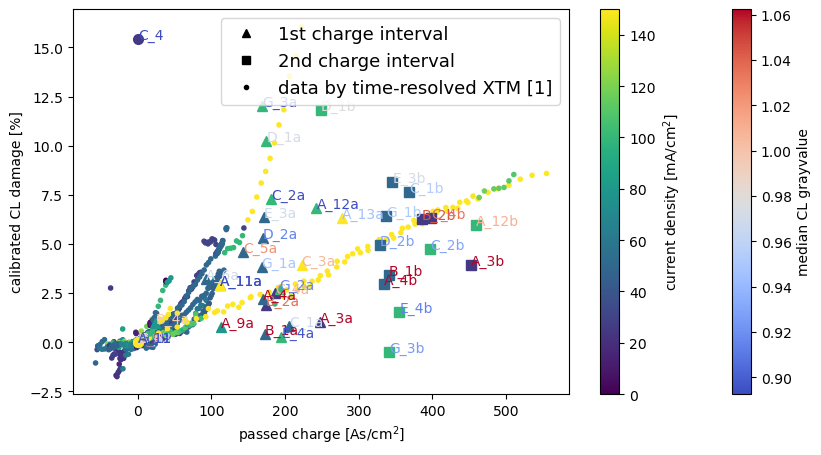

In [38]:
norm = Normalize(vmin=0,vmax=150)
d = 0.0075
norm2 = Normalize(vmin=0.9-d,vmax=1.07-d)
fig, ax = plt.subplots(figsize = (10,5))
cmap = cm.viridis #inferno
cmap2 = cm.coolwarm # bwr
ax.scatter(df['charge'], df['damage'],marker='.', c = cmap(norm(df['current'])))#, alpha = 0.5)
ax.plot(0,0,'k^', label='1st charge interval')
ax.plot(0,0,'ks', label='2nd charge interval')
ax.plot(0,0,'k.', label='data by time-resolved XTM [1]')
i = 0
for ab in current_25:
    # if ab == 'C_4': continue
    plot_damage_vs_charge(ab,25, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,25, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50:
    plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_100:
    plot_damage_vs_charge(ab,100, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,100, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_150:
    # if ab == 'Z_4': continue
    plot_damage_vs_charge(ab,150, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,150, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_80_special:
    plot_damage_vs_charge(ab,80, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,80, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50_special:
    plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_high_special:
    plot_damage_vs_charge(ab,250,norm, ax, norm2, cmap, cmap2)
    # plot_damage_vs_charge_v2(ab,250,norm, ax, norm2, cmap, cmap2)
    i = i+1
# plt.legend()   
ax.set_xlabel('passed charge [As/cm$^2$]')
# plt.ylabel('Q [As/cm2]')
ax.set_ylabel('calibrated CL damage [%]')
fig.colorbar(plt.cm.ScalarMappable(norm=norm2, cmap=cmap2),
             ax=ax, label='median CL grayvalue')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             ax=ax, label='current density [mA/cm$^2$]')



# plt.ylim(0)
m0 = 0.0155
# linear(m0,5, label = 'initial charge-damage relation')
# plt.ylim(0,20)
# plt.xlim(0,500)
plt.rc('legend', fontsize=13) #fontsize of the legend
plt.legend()
plt.rc('axes', labelsize=18) #fontsize of the x and y labels
# plt.savefig('/mpc/homes/fische_r/paper/07-coely-postmortem/sketch_images/charge_damage_with_tomcat.pdf', bbox_inches='tight')

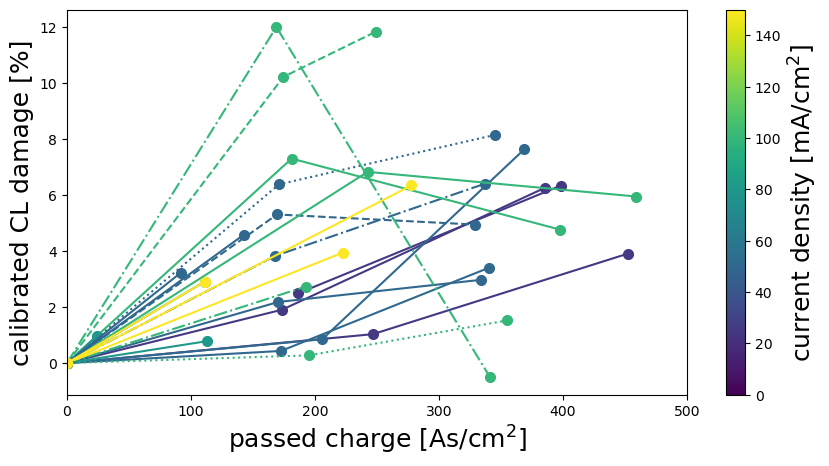

In [38]:
norm = Normalize(vmin=0,vmax=150)
d = 0.0075
norm2 = Normalize(vmin=0.9-d,vmax=1.07-d)
fig, ax = plt.subplots(figsize = (10,5))
cmap = cm.viridis #inferno
cmap2 = cm.coolwarm # bwr
# ax.scatter(df['charge'], df['damage'],marker='.', c = cmap(norm(df['current'])))#, alpha = 0.5)
ax.plot(0,0,'k^', label='1st charge interval')
ax.plot(0,0,'ks', label='2nd charge interval')
ax.plot(0,0,'k.', label='data by time-resolved XTM [1]')
i = 0
for ab in current_25:
    # if ab == 'C_4': continue
    # plot_damage_vs_charge(ab,25, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,25, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50:
    # plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_100:
    # plot_damage_vs_charge(ab,100, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,100, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_150:
    # if ab == 'Z_4': continue
    # plot_damage_vs_charge(ab,150, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,150, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_80_special:
    # plot_damage_vs_charge(ab,80, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,80, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50_special:
    # plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_high_special:
    # plot_damage_vs_charge(ab,250,norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v2(ab,250,norm, ax, norm2, cmap, cmap2)
    i = i+1
# plt.legend()   
ax.set_xlabel('passed charge [As/cm$^2$]')
# plt.ylabel('Q [As/cm2]')
ax.set_ylabel('calibrated CL damage [%]')
# fig.colorbar(plt.cm.ScalarMappable(norm=norm2, cmap=cmap2),
#              ax=ax, label='median CL grayvalue')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             ax=ax, label='current density [mA/cm$^2$]')



# plt.ylim(0)
m0 = 0.0155
# linear(m0,5, label = 'initial charge-damage relation')
# plt.ylim(0,20)
plt.xlim(0,500)
# plt.rc('legend', fontsize=13) #fontsize of the legend
# plt.legend()
plt.rc('axes', labelsize=18) #fontsize of the x and y labels
# plt.savefig('/mpc/homes/fische_r/paper/07-coely-postmortem/sketch_images/charge_damage_with_tomcat.pdf', bbox_inches='tight')

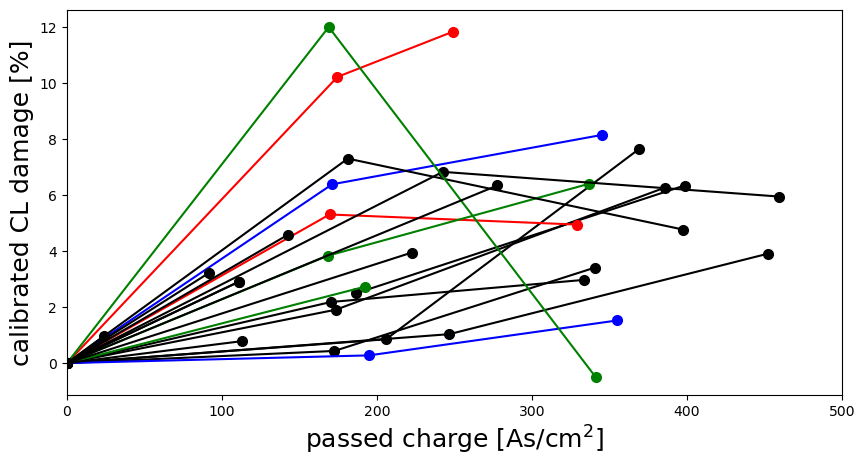

In [41]:
norm = Normalize(vmin=0,vmax=150)
d = 0.0075
norm2 = Normalize(vmin=0.9-d,vmax=1.07-d)
fig, ax = plt.subplots(figsize = (10,5))
cmap = cm.viridis #inferno
cmap2 = cm.coolwarm # bwr
# ax.scatter(df['charge'], df['damage'],marker='.', c = cmap(norm(df['current'])))#, alpha = 0.5)
ax.plot(0,0,'k^', label='1st charge interval')
ax.plot(0,0,'ks', label='2nd charge interval')
ax.plot(0,0,'k.', label='data by time-resolved XTM [1]')
i = 0
for ab in current_25:
    # if ab == 'C_4': continue
    # plot_damage_vs_charge(ab,25, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,25, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50:
    # plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_100:
    # plot_damage_vs_charge(ab,100, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,100, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_150:
    # if ab == 'Z_4': continue
    # plot_damage_vs_charge(ab,150, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,150, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_80_special:
    # plot_damage_vs_charge(ab,80, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,80, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_50_special:
    # plot_damage_vs_charge(ab,50, norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,50, norm, ax, norm2, cmap, cmap2)
    i = i+1
i = 0
for ab in current_high_special:
    # plot_damage_vs_charge(ab,250,norm, ax, norm2, cmap, cmap2)
    plot_damage_vs_charge_v3(ab,250,norm, ax, norm2, cmap, cmap2)
    i = i+1
# plt.legend()   
ax.set_xlabel('passed charge [As/cm$^2$]')
# plt.ylabel('Q [As/cm2]')
ax.set_ylabel('calibrated CL damage [%]')

plt.xlim(0,500)
# plt.rc('legend', fontsize=13) #fontsize of the legend
# plt.legend()
plt.rc('axes', labelsize=18) #fontsize of the x and y labels
# plt.savefig('/mpc/homes/fische_r/paper/07-coely-postmortem/sketch_images/charge_damage_with_tomcat.pdf', bbox_inches='tight')

In [ ]:
hole_dict['G']

In [35]:
med_dict = hole_dict.copy()

Text(0, 0.5, 'median CL layer gravalue maximum')

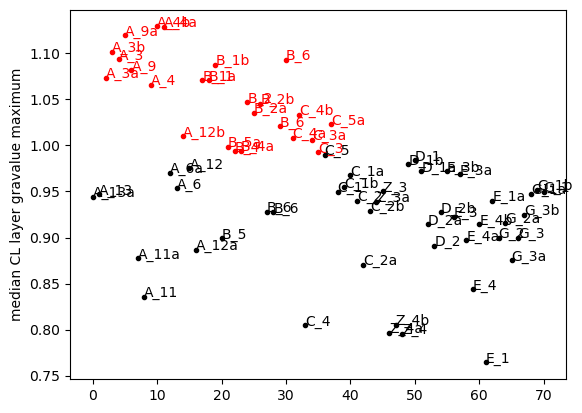

In [36]:
k = 0
for (ip, med) in zip(image_paths, meds):
    ser = ip[0]
    sample = ip[1]
    stage = ip[2]
    txt = ser+'_'+sample
    if stage == 'postop_1':
        txt = txt+'a'
    if stage == 'postop_2':
        txt = txt+'b'
    color='k'
    med_dict[ser][sample][stage] = med
    if med > 0.99263966: color = 'r'
    plt.plot(k, med, '.', color=color)
    plt.annotate(txt, (k, med),color=color)
    k = k+1

plt.ylabel('median CL layer gravalue maximum')

In [44]:
test = skimage.io.imread(os.path.join(toppath, 'G_normalized', 'G_1_postop_1__normalized.tif'))

# Figures for paper